In [1]:
#importing required python classes and packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading & displaying healthcare dataset
dataset = pd.read_csv("Dataset/human_vital.csv")
dataset

,Heart Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Derived_BMI,Risk Category
0,60,36.861707,95.702046,124,86,37,Female,32.459031,High Risk
1,63,36.511633,96.689413,126,84,77,Male,12.771246,High Risk
2,63,37.052049,98.508265,131,78,68,Female,28.821069,Low Risk
3,99,36.654748,95.011801,118,72,41,Female,28.554611,High Risk
4,69,36.975098,98.623792,138,76,25,Female,16.081438,High Risk
...,...,...,...,...,...,...,...,...,...
19995,98,36.830900,95.382739,118,89,44,Male,28.383996,High Risk
19996,64,36.142096,97.200470,122,74,53,Female,21.916337,Low Risk
19997,93,36.193259,99.003296,122,73,78,Male,15.463167,High Risk
19998,88,37.289717,96.856314,128,83,52,Female,34.539525,High Risk


In [3]:
#displaying dataset information with column names and its supporting data type
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Heart Rate                20000 non-null  int64  
 1   Body Temperature          20000 non-null  float64
 2   Oxygen Saturation         20000 non-null  float64
 3   Systolic Blood Pressure   20000 non-null  int64  
 4   Diastolic Blood Pressure  20000 non-null  int64  
 5   Age                       20000 non-null  int64  
 6   Gender                    20000 non-null  object 
 7   Derived_BMI               20000 non-null  float64
 8   Risk Category             20000 non-null  object 
dtypes: float64(3), int64(4), object(2)
memory usage: 1.4+ MB


In [4]:
#describing dataset with details like count, mean, standard deviation of each dataset attributes
dataset.describe()

,Heart Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Derived_BMI
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,79.556750,36.748909,97.502673,124.403600,79.504800,53.397400,25.047894
std,11.573257,0.434117,1.436675,8.649829,5.758353,20.777804,6.466935
min,60.000000,36.000004,95.000041,110.000000,70.000000,18.000000,12.547355
25%,70.000000,36.373909,96.263571,117.000000,75.000000,35.000000,20.190364
50%,80.000000,36.750118,97.512433,124.000000,79.000000,53.000000,24.366296
75%,90.000000,37.125651,98.752351,132.000000,85.000000,71.000000,29.196420
max,99.000000,37.499895,99.999585,139.000000,89.000000,89.000000,44.347255


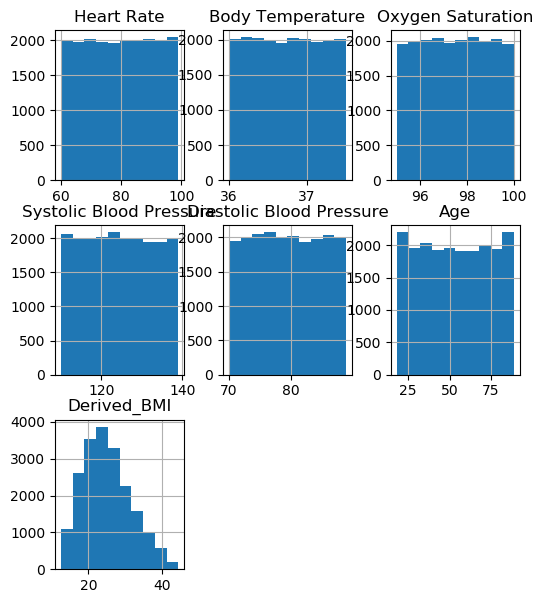

In [5]:
#visualizing distribution of numerical data
dataset.hist(figsize=(6, 7))
plt.title("Representation of Dataset Attributes")
plt.show()

In [6]:
#finding sum of missing values
dataset.isnull().sum()

Heart Rate                  0
Body Temperature            0
Oxygen Saturation           0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
Age                         0
Gender                      0
Derived_BMI                 0
Risk Category               0
dtype: int64

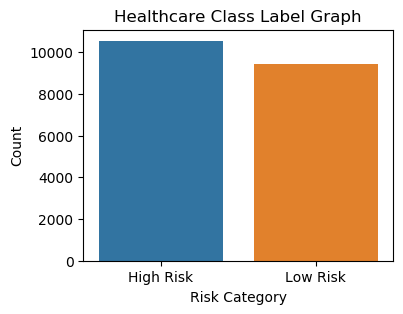

In [7]:
#graphs of different risk and non-risk labels available in dataset
disease_data = dataset.groupby(["Risk Category"]).size().reset_index(name='Count') 
plt.figure(figsize=(4, 3))
sns.barplot(data=disease_data, x='Risk Category', y='Count')
plt.title("Healthcare Class Label Graph")
plt.show() 

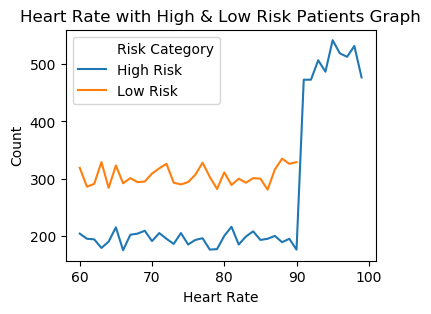

In [8]:
#graphs of heart rate in high and low risk patinets
heart_rate = dataset.groupby(["Heart Rate","Risk Category"]).size().reset_index(name='Count') 
plt.figure(figsize=[4,3])
sns.lineplot(x="Heart Rate", y='Count', hue='Risk Category',data=heart_rate)
plt.title("Heart Rate with High & Low Risk Patients Graph")
plt.show()

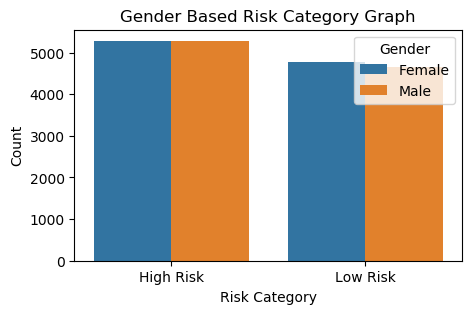

In [9]:
#gender based High and low health risk graph
data = dataset.groupby(['Gender','Risk Category']).size().reset_index(name="Count")
plt.figure(figsize=[5,3])
sns.barplot(x="Risk Category",y="Count",hue='Gender',data=data)
plt.title("Gender Based Risk Category Graph")
plt.show()

In [10]:
labels = np.unique(dataset['Risk Category']).ravel()
#applying dataset processing technique to convert non-numeric data to numeric data as label encoding
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for j in range(len(types)):
    name = types[j]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[j]] = pd.Series(le.fit_transform(dataset[columns[j]].astype(str)))#encode all str columns to numeric
        label_encoder.append([columns[j], le])
dataset.fillna(dataset.mean(), inplace = True)#replacing missing values using mean imputation
dataset

,Heart Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Derived_BMI,Risk Category
0,60,36.861707,95.702046,124,86,37,0,32.459031,0
1,63,36.511633,96.689413,126,84,77,1,12.771246,0
2,63,37.052049,98.508265,131,78,68,0,28.821069,1
3,99,36.654748,95.011801,118,72,41,0,28.554611,0
4,69,36.975098,98.623792,138,76,25,0,16.081438,0
...,...,...,...,...,...,...,...,...,...
19995,98,36.830900,95.382739,118,89,44,1,28.383996,0
19996,64,36.142096,97.200470,122,74,53,0,21.916337,1
19997,93,36.193259,99.003296,122,73,78,1,15.463167,0
19998,88,37.289717,96.856314,128,83,52,0,34.539525,0


In [11]:
#extracting target value from dataset
Y = dataset['Risk Category'].ravel()
dataset.drop(['Risk Category'], axis = 1,inplace=True)
#shuffling and normalizing dataset features
X = dataset.values
scaler = MinMaxScaler((0,1))
X = scaler.fit_transform(X)#normalizing dataset features
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle dataset values
X = X[indices]
Y = Y[indices]
print('Normalized Features = '+str(X))

Normalized Features = [[0.02564103 0.83464551 0.9020402  ... 0.25352113 0.         0.25898731]
 [0.38461538 0.21533469 0.74481068 ... 1.         1.         0.25059745]
 [0.82051282 0.125314   0.88640898 ... 0.16901408 1.         0.35313854]
 ...
 [0.92307692 0.32064715 0.11393579 ... 0.74647887 1.         0.4213082 ]
 [0.71794872 0.391691   0.4107834  ... 0.98591549 1.         0.41679122]
 [0.64102564 0.29482103 0.93038771 ... 0.57746479 0.         0.16626476]]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Split Details")
print("80% dataset features used to train algorithms : "+str(X_train.shape[0]))
print("20% dataset features used to test algorithms : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Dataset Split Details
80% dataset features used to train algorithms : 16000
20% dataset features used to test algorithms : 4000


In [13]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [14]:
#function to evaluate model
def modelEvaluation(algorithm, testY, predict):
    p = round(precision_score(testY, predict,average='macro') * 100, 2)
    r = round(recall_score(testY, predict,average='macro') * 100, 2)
    f = round(f1_score(testY, predict,average='macro') * 100, 2)
    a = round(accuracy_score(testY,predict)*100, 2)
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 

    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()

SVM Accuracy  : 94.5
SVM Precision : 94.48
SVM Recall    : 94.57
SVM FSCORE    : 94.49


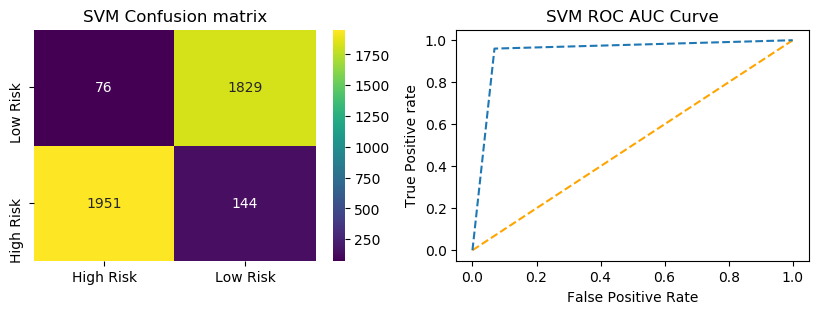

In [15]:
#train SVM on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
svm_cls = svm.SVC()
#train model on training features
svm_cls.fit(X_train, y_train)
#call this function to predict on test data
predict = svm_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("SVM", y_test, predict)

Random Forest Accuracy  : 99.95
Random Forest Precision : 99.95
Random Forest Recall    : 99.95
Random Forest FSCORE    : 99.95


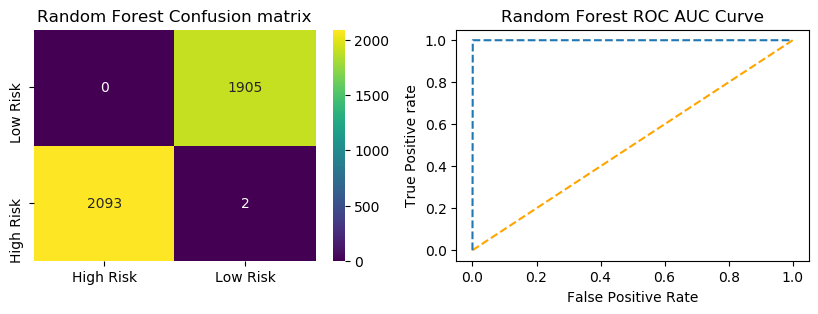

In [16]:
#train Random Forest algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
rf_cls = RandomForestClassifier(max_depth=None)
#train model on training features
rf_cls.fit(X_train, y_train)
#call this function to predict on test data
predict = rf_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Random Forest", y_test, predict)

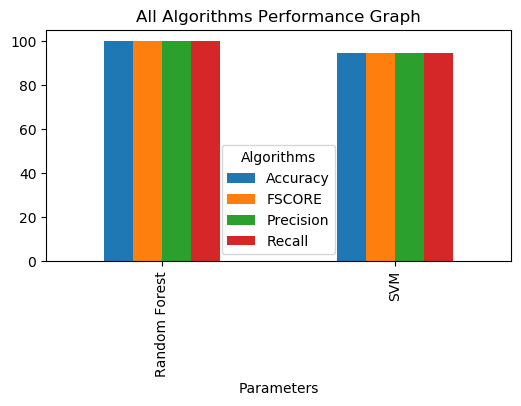

In [17]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['SVM','Accuracy',accuracy[0]],['SVM','Precision',precision[0]],['SVM','Recall',recall[0]],['SVM','FSCORE',fscore[0]],
                   ['Random Forest','Accuracy',accuracy[1]],['Random Forest','Precision',precision[1]],['Random Forest','Recall',recall[1]],['Random Forest','FSCORE',fscore[1]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph")
plt.show()


In [19]:
algorithms = ['SVM', 'Random Forest']

data = []
for a, acc, pre, rec, fs in zip(algorithms, accuracy, precision, recall, fscore):
    data.append([a, acc, pre, rec, fs])

data = pd.DataFrame(data, columns=['Algorithm Name','Accuracy','Precision','Recall','FSCORE'])
data

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,SVM,94.50,94.48,94.57,94.49
1,Random Forest,99.95,99.95,99.95,99.95


In [20]:
#loading test data and then applying extension model to predict type of attack
testData = pd.read_csv("Dataset/testData.csv")#load test data
data = testData.copy()
for i in range(len(label_encoder)-1):#label encoding from non-numeric to numeric
    le = label_encoder[i]
    testData[le[0]] = pd.Series(le[1].transform(testData[le[0]].astype(str)))#encode all str columns to numeric
testData.fillna(dataset.mean(), inplace = True)#replace misisng values with mean    
testData = testData.values    
testData = scaler.transform(testData)#normalize test data
predict = rf_cls.predict(testData)#apply best model to predict patient risk
pred = []
for i in range(len(predict)):
    pred.append(labels[predict[i]])
data['Predicted Health Status'] = pred
data = data.style.set_properties(**{'background-color': 'yellow'}, subset=['Predicted Health Status'])
data

,Heart Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Derived_BMI,Predicted Health Status
0,98,37.128593,96.989711,135,71,58,Male,24.571196,High Risk
1,93,36.737355,98.258727,132,88,52,Male,24.727955,High Risk
2,84,36.564140,98.943037,117,86,24,Male,27.691265,Low Risk
3,81,37.306581,97.989803,131,74,81,Female,29.104099,Low Risk
4,64,36.830260,97.721849,111,81,24,Female,22.385613,Low Risk
5,91,37.281491,99.098619,115,88,20,Female,13.944536,High Risk
6,71,36.621030,97.188938,130,85,64,Female,24.607713,Low Risk
7,97,36.843447,95.704241,118,89,30,Male,15.160970,High Risk
8,67,36.729283,99.342862,119,89,20,Male,26.476892,Low Risk
9,82,36.950985,97.171997,127,71,62,Female,28.161739,Low Risk
